In [22]:
# ==========================================
# 1. IMPORTS & SETUP
# ==========================================
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from PIL import Image
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# ==========================================
# 2. LOAD & PREPROCESS DATA
# ==========================================

base_path = '/content/drive/MyDrive/Face_Dataset/'
class_names = sorted(os.listdir(base_path))
num_classes = len(class_names)
print(f"Classes found: {class_names}")

x_data = []
y_data = []

# ResNet50 requires 224x224 RGB images
target_size = (224, 224)

print("Loading images...")
for idx, name in enumerate(class_names):
    folder_path = os.path.join(base_path, name)

    # Check if folder exists to avoid errors
    if not os.path.isdir(folder_path):
        continue

    for img_name in os.listdir(folder_path):
        img_path = os.path.join(folder_path, img_name)
        try:
            # Open image and ensure it is RGB
            img = Image.open(img_path).convert('RGB')
            img = img.resize(target_size)
            img_array = np.array(img)

            x_data.append(img_array)
            y_data.append(idx)
        except Exception as e:
            print(f"Skipped bad image: {img_name}")

x_data = np.array(x_data)
y_data = np.array(y_data)

print(f"Total images: {len(x_data)}")
print(f"Image shape: {x_data.shape}")

Classes found: ['Abir', 'DIPANKAR', 'Mehedi']
Loading images...
Skipped bad image: IMG_6340.HEIC
Skipped bad image: IMG_6342.HEIC
Skipped bad image: IMG_6336.HEIC
Skipped bad image: IMG_6341.HEIC
Skipped bad image: IMG_6345.HEIC
Total images: 36
Image shape: (36, 224, 224, 3)


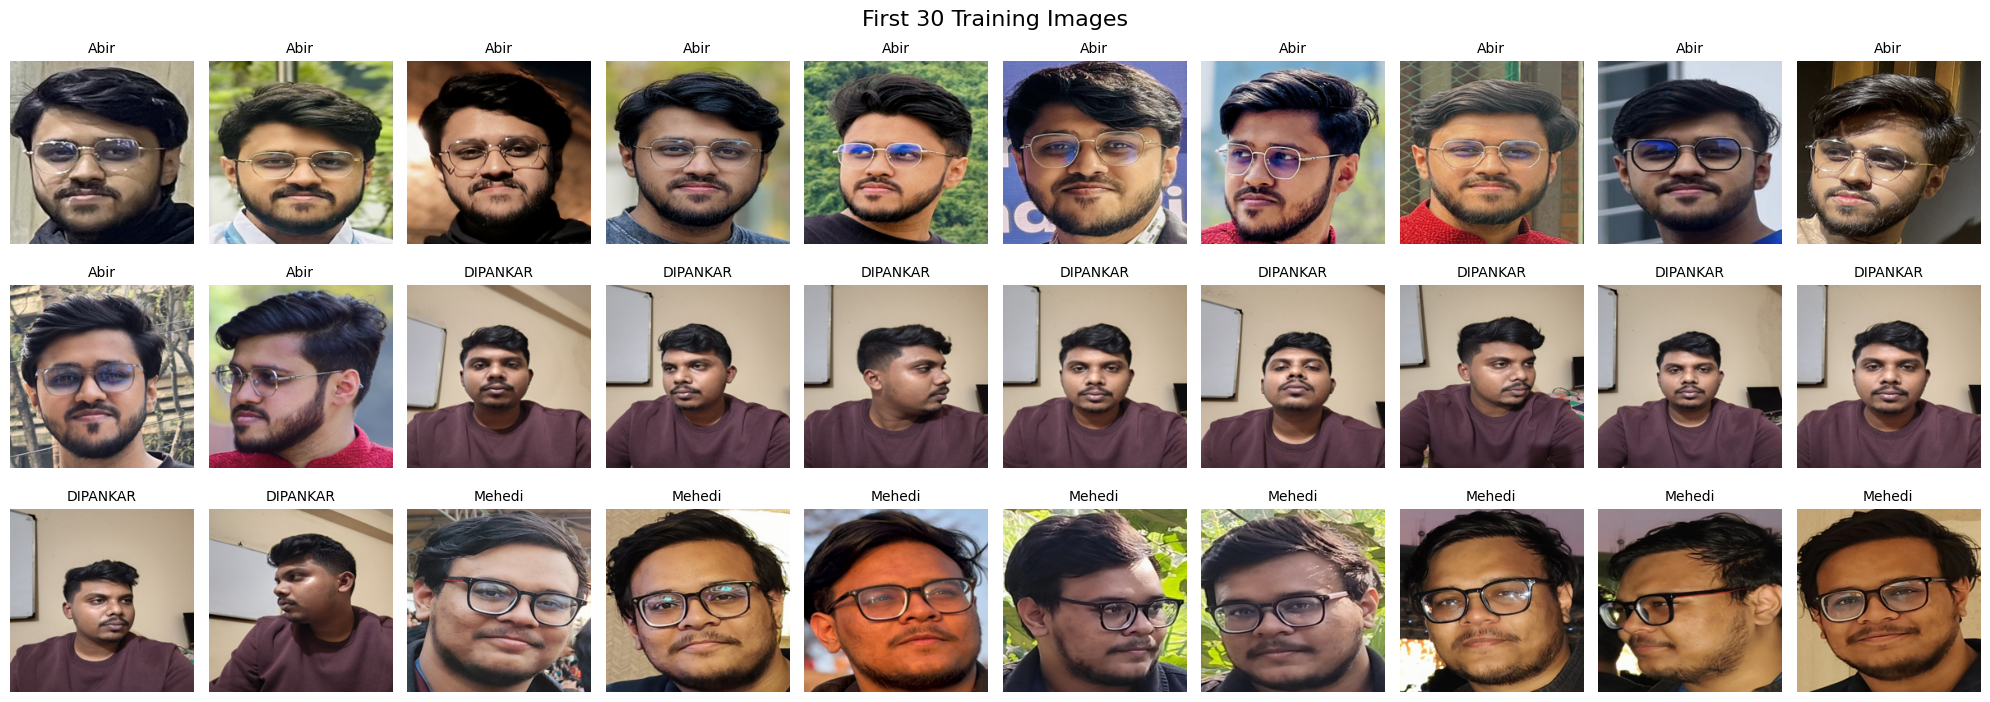

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 7))

for i in range(30):
    if i >= len(x_data):
        break

    plt.subplot(3, 10, i + 1)


    plt.imshow(x_data[i].astype('uint8'))

    # Get the label name
    label_index = y_data[i]
    plt.title(class_names[label_index], fontsize=10)
    plt.axis('off')

plt.tight_layout()
plt.suptitle("First 30 Training Images", fontsize=16, y=1.02)
plt.show()

In [ ]:
# Split Training and Validation Data
x_train, x_test, y_train, y_test = train_test_split(
    x_data, y_data, test_size=0.2, random_state=42, stratify=y_data
)

# Apply ResNet specific preprocessing
x_train = preprocess_input(x_train.copy())
x_test = preprocess_input(x_test.copy())

# One-hot encode labels
y_train = keras.utils.to_categorical(y_train, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)

In [26]:
# ==========================================
# 3. BUILD TRANSFER LEARNING MODEL
# ==========================================
# Load ResNet50 with pre-trained ImageNet weights
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze the base model layers
base_model.trainable = False

# Create the new model
inputs = keras.Input(shape=(224, 224, 3))

# Data Augmentation (Optional but recommended for small datasets)
x = layers.RandomFlip("horizontal")(inputs)
x = layers.RandomRotation(0.1)(x)

# Pass inputs through the pre-trained base
x = base_model(x, training=False)

# Add custom classification head
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.5)(x)  # Reduces overfitting
outputs = layers.Dense(num_classes, activation='softmax')(x)

model = keras.Model(inputs, outputs)
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip_1 (RandomFlip)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_1               │ (None, 224, 224, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │         6,147 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,593,859 (90.00 MB)

 Trainable params: 6,147 (24.01 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [27]:
# ==========================================
# 4. TRAIN THE HEAD (Phase 1)
# ==========================================
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("\n--- Phase 1: Training Top Layers ---")
history = model.fit(
    x_train, y_train,
    epochs=10,
    validation_data=(x_test, y_test),
    batch_size=8
)


--- Phase 1: Training Top Layers ---
Epoch 1/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 18s 3s/step - accuracy: 0.4262 - loss: 1.4603 - val_accuracy: 0.5000 - val_loss: 0.9393
Epoch 2/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.4024 - loss: 1.1965 - val_accuracy: 0.7500 - val_loss: 0.7442
Epoch 3/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - accuracy: 0.6571 - loss: 0.9343 - val_accuracy: 0.7500 - val_loss: 0.6121
Epoch 4/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.7768 - loss: 0.6318 - val_accuracy: 0.8750 - val_loss: 0.4478
Epoch 5/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - accuracy: 0.8821 - loss: 0.3796 - val_accuracy: 0.8750 - val_loss: 0.3628
Epoch 6/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.7976 - loss: 0.5061 - val_accuracy: 0.8750 - val_loss: 0.2990
Epoch 7/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - accuracy: 0.8119 - loss: 0.5147 - val_accuracy: 1.0000 - val_loss: 0.2594
Epoch 8/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.8077 - loss: 0.3865 - val_accuracy: 1.0

In [ ]:
# ==========================================
# 5. FINE-TUNING (Phase 2)
# ==========================================
# Unfreeze the base model to fine-tune weights
base_model.trainable = True

# Freeze earlier layers to keep low-level features stable
for layer in base_model.layers[:100]:
    layer.trainable = False

# Recompile with a very low learning rate
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5), # 0.00001
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("\n--- Phase 2: Fine-Tuning ---")
history_fine = model.fit(
    x_train, y_train,
    epochs=10,
    validation_data=(x_test, y_test),
    batch_size=8
)


--- Phase 2: Fine-Tuning ---
Epoch 1/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 44s 4s/step - accuracy: 0.9280 - loss: 0.3646 - val_accuracy: 1.0000 - val_loss: 0.2387
Epoch 2/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 13s 3s/step - accuracy: 0.9012 - loss: 0.3274 - val_accuracy: 1.0000 - val_loss: 0.2180
Epoch 3/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 21s 3s/step - accuracy: 0.7875 - loss: 0.3134 - val_accuracy: 1.0000 - val_loss: 0.1992
Epoch 4/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 15s 4s/step - accuracy: 0.8869 - loss: 0.2854 - val_accuracy: 1.0000 - val_loss: 0.1854
Epoch 5/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 12s 3s/step - accuracy: 0.8661 - loss: 0.3225 - val_accuracy: 1.0000 - val_loss: 0.1727
Epoch 6/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 21s 3s/step - accuracy: 0.9399 - loss: 0.2366 - val_accuracy: 1.0000 - val_loss: 0.1638
Epoch 7/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 13s 3s/step - accuracy: 0.9423 - loss: 0.1428 - val_accuracy: 1.0000 - val_loss: 0.1552
Epoch 8/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 19s 3s/step - accuracy: 0.8946 - loss: 0.2440 - val_accuracy: 1.00

In [ ]:
# ==========================================
# 6. SAVE MODEL
# ==========================================
save_path = '/content/drive/MyDrive/Face_Attendance_Model/face_recognition_resnet.keras'
# Creates directory if it doesn't exist
os.makedirs(os.path.dirname(save_path), exist_ok=True)

model.save(save_path)
print(f"✅ Model saved successfully at: {save_path}")

✅ Model saved successfully at: /content/drive/MyDrive/Face_Attendance_Model/face_recognition_resnet.keras
